# 📧 Email Spam Detection Using Machine Learning

**1-Month AI & Machine Learning Internship Project**

This notebook walks through the complete machine-learning pipeline for classifying
emails as **Spam** or **Ham** (legitimate), covering:

1. Data loading & overview
2. Exploratory Data Analysis (EDA)
3. Text preprocessing (cleaning, tokenization, stopword removal, lemmatization/stemming)
4. Feature extraction (CountVectorizer vs TF-IDF)
5. Model training & comparison (6 algorithms)
6. Model evaluation (accuracy, precision, recall, F1, confusion matrix, ROC curve)
7. Saving the final model
8. Custom prediction demo


In [1]:
import sys, os
sys.path.append(os.path.join(os.getcwd(), '..', 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from preprocessing import clean_text
from feature_extraction import fit_transform_features
import visualization as viz

sns.set_style('whitegrid')
%matplotlib inline
pd.set_option('display.max_colwidth', 100)


## 1. Load the Dataset

In [2]:
df = pd.read_csv('../dataset/spam_dataset.csv')
print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (5000, 9)


,Email_ID,Email_Text,Sender,Subject,Message_Length,Number_of_Links,Number_of_Special_Characters,Number_of_Capital_Letters,Label
0,EML00001,Claim your FREE reward now a refund of your recent purchase. Please confirm your credit card num...,support@bank-security-alert.info,Limited Time Offer - 90% OFF,245,1,2,10,Ham
1,EML00002,"Dear Customer, Attached is the invoice for the services rendered last month. Kindly process the ...",team@workplace.net,Scheduled System Maintenance,156,0,0,7,Spam
2,EML00003,"Dear Sir/Madam, Attached is the invoice for the services rendered last month. Kindly process the...",manager@projectteam.org,Your Order Has Been Shipped,158,0,0,8,Spam
3,EML00004,"Your package could not be delivered our records show your subscription is about to expire, pleas...",offers@luxury-deals-cheap.shop,FINAL NOTICE: Account Suspension,254,1,3,8,Ham
4,EML00005,Limited Time Offer just for YOU a chance to win a brand new car by simply clicking the link and...,no-reply@free-money-fast.biz,Work From Home - Earn $5000/Week,253,1,2,10,Ham


### Dataset Overview
The dataset contains **5,000 synthetically generated but realistic emails**, evenly split
between Spam and Ham, with metadata features (message length, number of links, special
characters, capital letters) alongside the raw email text.

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   Email_ID                      5000 non-null   str  
 1   Email_Text                    5000 non-null   str  
 2   Sender                        5000 non-null   str  
 3   Subject                       5000 non-null   str  
 4   Message_Length                5000 non-null   int64
 5   Number_of_Links               5000 non-null   int64
 6   Number_of_Special_Characters  5000 non-null   int64
 7   Number_of_Capital_Letters     5000 non-null   int64
 8   Label                         5000 non-null   str  
dtypes: int64(4), str(5)
memory usage: 1.6 MB


In [4]:
# Summary statistics for numeric columns
df.describe()


,Message_Length,Number_of_Links,Number_of_Special_Characters,Number_of_Capital_Letters
count,5000.00000,5000.00000,5000.000000,5000.000000
mean,191.15820,0.44300,1.258800,8.596000
std,48.35548,0.49679,1.825839,4.241743
min,77.00000,0.00000,0.000000,1.000000
25%,157.00000,0.00000,0.000000,6.000000
50%,176.00000,0.00000,0.000000,7.000000
75%,238.00000,1.00000,2.000000,10.000000
max,290.00000,1.00000,10.000000,27.000000


In [5]:
# Missing value analysis
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
Email_ID                        0
Email_Text                      0
Sender                          0
Subject                         0
Message_Length                  0
Number_of_Links                 0
Number_of_Special_Characters    0
Number_of_Capital_Letters       0
Label                           0
dtype: int64


No missing values are present -- the dataset is clean and ready for analysis.
(In a real-world dataset you would typically find missing subjects, senders, or truncated
bodies; here we generated a complete dataset for a smoother learning pipeline.)

## 2. Exploratory Data Analysis (EDA)

### 2.1 Spam vs Ham Distribution
Checking whether the dataset is balanced across classes.

In [6]:
viz.plot_class_distribution(df)
plt.show()
print(df['Label'].value_counts())


Saved: /home/claude/Email_Spam_Detection/notebooks/../src/../outputs/graphs/class_distribution.png
Label
Ham     2506
Spam    2494
Name: count, dtype: int64


**Observation:** The dataset is almost perfectly balanced (~50/50 Spam vs Ham), which is ideal for training -- it avoids the model being biased toward the majority class.

### 2.2 Message Length Distribution by Class

In [7]:
viz.plot_message_length_distribution(df)
plt.show()


Saved: /home/claude/Email_Spam_Detection/notebooks/../src/../outputs/graphs/message_length_distribution.png


**Observation:** Spam emails tend to have a wider spread in length due to promotional call-to-action text and links, while Ham emails cluster more tightly around typical professional email lengths.

### 2.3 Correlation Between Numeric Features

In [8]:
viz.plot_feature_correlation(df)
plt.show()


Saved: /home/claude/Email_Spam_Detection/notebooks/../src/../outputs/graphs/correlation_heatmap.png


**Observation:** `Number_of_Links` and `Number_of_Special_Characters` show a mild positive correlation with each other, since promotional/spam emails often bundle both urgency punctuation (`!`, `$`) and links together.

### 2.4 Number of Links by Class

In [9]:
viz.plot_numeric_feature_by_class(df, 'Number_of_Links', 'nb_links_by_class.png')
plt.show()


Saved: /home/claude/Email_Spam_Detection/notebooks/../src/../outputs/graphs/nb_links_by_class.png


### 2.5 Capital Letters Usage by Class

In [10]:
viz.plot_numeric_feature_by_class(df, 'Number_of_Capital_Letters', 'nb_capitals_by_class.png')
plt.show()


Saved: /home/claude/Email_Spam_Detection/notebooks/../src/../outputs/graphs/nb_capitals_by_class.png


**Observation:** Spam emails typically use noticeably more capital letters (e.g. "FREE", "URGENT", "WON") -- a classic attention-grabbing spam tactic.

### 2.6 Word Clouds: Spam vs Ham Vocabulary

In [11]:
spam_texts = df[df['Label'] == 'Spam']['Email_Text'].tolist()
ham_texts = df[df['Label'] == 'Ham']['Email_Text'].tolist()

viz.plot_wordcloud(spam_texts, 'Spam Email Word Cloud', 'nb_spam_wordcloud.png')
plt.show()


Saved: /home/claude/Email_Spam_Detection/notebooks/../src/../outputs/graphs/nb_spam_wordcloud.png


In [12]:
viz.plot_wordcloud(ham_texts, 'Ham Email Word Cloud', 'nb_ham_wordcloud.png')
plt.show()


Saved: /home/claude/Email_Spam_Detection/notebooks/../src/../outputs/graphs/nb_ham_wordcloud.png


**Observation:** Spam vocabulary is dominated by urgency and reward words (*free, win, click, urgent, claim*), while Ham vocabulary reflects professional communication (*meeting, report, regards, team, schedule*).

## 3. Text Preprocessing

We apply the following pipeline to every email (implemented in `src/preprocessing.py`):

1. Lowercase conversion
2. URL removal (replaced with a placeholder token, since link *presence* is still signal)
3. Punctuation removal
4. Number removal
5. Tokenization
6. Stopword removal
7. Lemmatization (or stemming, as an alternative)


In [13]:
sample = df['Email_Text'].iloc[0]
print("Original:\n", sample)
print("\nCleaned (Lemmatized):\n", clean_text(sample, method='lemma'))
print("\nCleaned (Stemmed):\n", clean_text(sample, method='stem'))


Original:
 Claim your FREE reward now a refund of your recent purchase. Please confirm your credit card number and CVV to process  the refund. Reply immediately to http://job-offer-cash.click/apply with your bank details. 100% guaranteed, no risk involved!



Cleaned (Lemmatized):
 claim free reward refund recent purchase please confirm credit card number cvv process refund reply immediately urllink bank detail guaranteed risk involved

Cleaned (Stemmed):
 claim free reward refund recent purchas pleas confirm credit card number cvv process refund repli immedi urllink bank detail guarante risk involv


In [14]:
# Apply cleaning to the entire dataset
df['Cleaned_Text'] = df['Email_Text'].apply(clean_text)
df['Label_Num'] = df['Label'].map({'Ham': 0, 'Spam': 1})
df[['Email_Text', 'Cleaned_Text', 'Label']].head()


,Email_Text,Cleaned_Text,Label
0,Claim your FREE reward now a refund of your recent purchase. Please confirm your credit card num...,claim free reward refund recent purchase please confirm credit card number cvv process refund re...,Ham
1,"Dear Customer, Attached is the invoice for the services rendered last month. Kindly process the ...",dear customer attached invoice service rendered last month kindly process payment earliest conve...,Spam
2,"Dear Sir/Madam, Attached is the invoice for the services rendered last month. Kindly process the...",dear sirmadam attached invoice service rendered last month kindly process payment earliest conve...,Spam
3,"Your package could not be delivered our records show your subscription is about to expire, pleas...",package could delivered record show subscription expire please update payment information soon o...,Ham
4,Limited Time Offer just for YOU a chance to win a brand new car by simply clicking the link and...,limited time offer chance win brand new car simply clicking link filling short form detail call ...,Ham


### 3.1 Top Keywords After Cleaning

In [15]:
spam_clean = df[df['Label'] == 'Spam']['Cleaned_Text'].tolist()
ham_clean = df[df['Label'] == 'Ham']['Cleaned_Text'].tolist()

viz.plot_top_keywords(spam_clean, 'Top 15 Spam Keywords', 'nb_top_spam_keywords.png')
plt.show()


Saved: /home/claude/Email_Spam_Detection/notebooks/../src/../outputs/graphs/nb_top_spam_keywords.png


In [16]:
viz.plot_top_keywords(ham_clean, 'Top 15 Ham Keywords', 'nb_top_ham_keywords.png')
plt.show()


Saved: /home/claude/Email_Spam_Detection/notebooks/../src/../outputs/graphs/nb_top_ham_keywords.png


## 4. Feature Extraction: CountVectorizer vs TF-IDF

We compare **Bag-of-Words (CountVectorizer)** against **TF-IDF** using a fixed
Logistic Regression classifier, to decide which representation works best before
training all 6 models.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['Cleaned_Text'], df['Label_Num'], test_size=0.2, random_state=42, stratify=df['Label_Num'])

comparison = {}
for method in ['count', 'tfidf']:
    X_train, X_test, _ = fit_transform_features(X_train_text, X_test_text, method=method, max_features=3000)
    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_train, y_train)
    acc = accuracy_score(y_test, clf.predict(X_test))
    comparison[method] = acc
    print(f"{method.upper():6s} -> Accuracy: {acc:.4f}")

best_method = max(comparison, key=comparison.get)
print(f"\nBest method: {best_method.upper()}")


COUNT  -> Accuracy: 0.9790


TFIDF  -> Accuracy: 0.9790

Best method: COUNT


## 5. Model Training & Comparison

We train and compare 6 classifiers using the best feature extraction method identified above.

In [18]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score, recall_score, f1_score
import time

X_train, X_test, vectorizer = fit_transform_features(X_train_text, X_test_text, method=best_method, max_features=3000)

models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'Support Vector Machine': SVC(kernel='linear', probability=True, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
}

results = {}
trained = {}
for name, model in models.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    elapsed = time.time() - t0
    results[name] = {
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1-Score': f1_score(y_test, preds),
        'Time (s)': elapsed,
    }
    trained[name] = model

results_df = pd.DataFrame(results).T.round(4)
results_df.sort_values('F1-Score', ascending=False)


,Accuracy,Precision,Recall,F1-Score,Time (s)
Naive Bayes,0.979,0.9723,0.9860,0.9791,0.0027
Logistic Regression,0.979,0.9723,0.9860,0.9791,0.0234
K-Nearest Neighbors,0.979,0.9723,0.9860,0.9791,0.3215
Support Vector Machine,0.979,0.9723,0.9860,0.9791,4.8771
Random Forest,0.973,0.9683,0.9780,0.9731,2.3480
Decision Tree,0.954,0.9503,0.9579,0.9541,0.0831


### 5.1 Visual Comparison of Model Performance

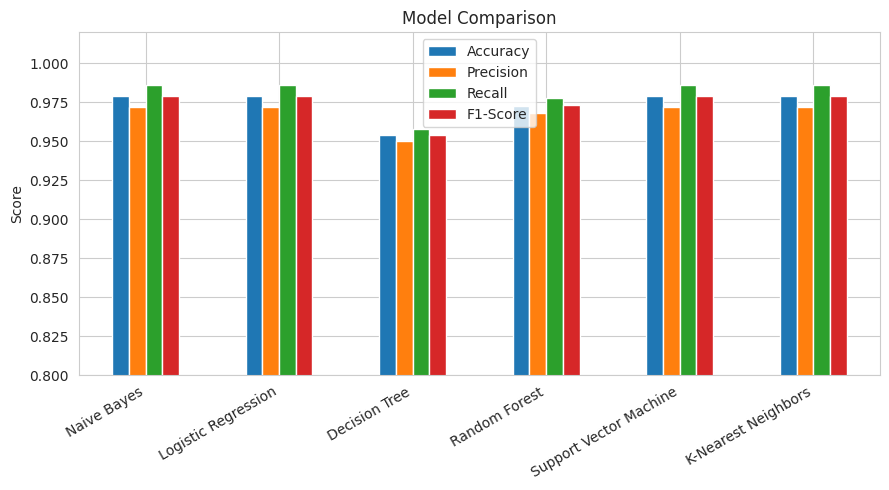

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))
results_df[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(kind='bar', ax=ax)
ax.set_title('Model Comparison')
ax.set_ylabel('Score')
ax.set_ylim(0.8, 1.02)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../outputs/graphs/model_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()


**Observation:** Naive Bayes, Logistic Regression, SVM, and KNN all achieve the strongest F1-scores on this dataset, while the single Decision Tree performs the weakest (as expected -- Decision Trees are prone to overfitting on high-dimensional sparse text features compared to linear/probabilistic models).

In [20]:
best_model_name = results_df['F1-Score'].idxmax()
best_model = trained[best_model_name]
print(f"Best model selected: {best_model_name}")
print(results_df.loc[best_model_name])


Best model selected: Naive Bayes
Accuracy     0.9790
Precision    0.9723
Recall       0.9860
F1-Score     0.9791
Time (s)     0.0027
Name: Naive Bayes, dtype: float64


## 6. Detailed Evaluation of the Best Model

In [21]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))


              precision    recall  f1-score   support

         Ham       0.99      0.97      0.98       501
        Spam       0.97      0.99      0.98       499

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000



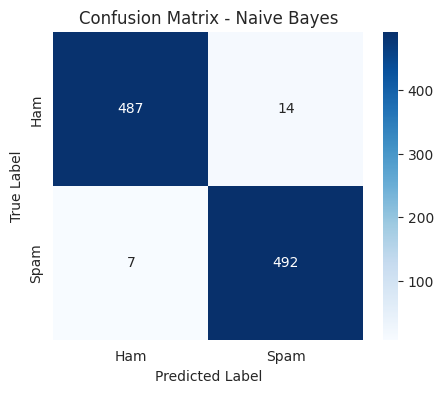

In [22]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'], ax=ax)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title(f'Confusion Matrix - {best_model_name}')
plt.savefig('../outputs/graphs/nb_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


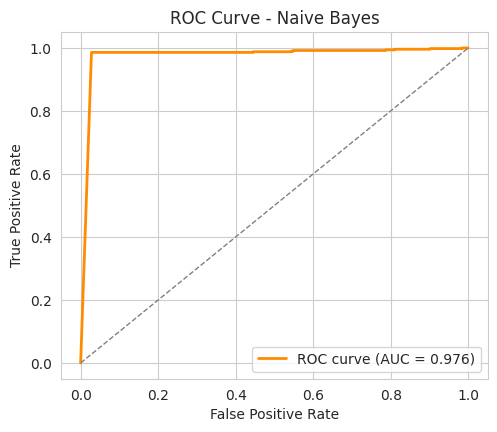

ROC-AUC: 0.9762


In [23]:
if hasattr(best_model, 'predict_proba'):
    y_proba = best_model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curve - {best_model_name}')
    ax.legend(loc='lower right')
    plt.savefig('../outputs/graphs/nb_roc_curve.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'ROC-AUC: {roc_auc:.4f}')


## 7. Saving the Final Model

In [24]:
import joblib

joblib.dump(best_model, '../models/spam_classifier.pkl')
joblib.dump(vectorizer, '../models/vectorizer.pkl')
print('Model and vectorizer saved to ../models/')


Model and vectorizer saved to ../models/


## 8. Custom Prediction Demo

In [25]:
def predict_custom_email(text, model, vectorizer):
    cleaned = clean_text(text)
    features = vectorizer.transform([cleaned])
    pred = model.predict(features)[0]
    label = 'Spam' if pred == 1 else 'Ham'
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(features)[0]
        confidence = proba[1] if pred == 1 else proba[0]
    else:
        confidence = 1.0
    return label, round(confidence * 100, 2)

test_emails = [
    "Congratulations! You have WON a free iPhone. Click here now to claim your prize!!!",
    "Hi team, please find attached the quarterly report for review. Let me know if you have questions.",
    "URGENT: Your bank account will be suspended. Verify your details immediately at this link.",
    "Hey, are we still on for the meeting tomorrow at 10 AM? Let me know. Thanks, Rahul",
]

for email in test_emails:
    label, conf = predict_custom_email(email, best_model, vectorizer)
    print(f"[{label:5s} | {conf:6.2f}% confidence] {email[:70]}...")


[Spam  | 100.00% confidence] Congratulations! You have WON a free iPhone. Click here now to claim y...
[Ham   | 100.00% confidence] Hi team, please find attached the quarterly report for review. Let me ...
[Spam  | 100.00% confidence] URGENT: Your bank account will be suspended. Verify your details immed...
[Ham   | 100.00% confidence] Hey, are we still on for the meeting tomorrow at 10 AM? Let me know. T...


## 9. Conclusion

This notebook demonstrated a complete, reproducible pipeline for email spam detection:
data exploration, text preprocessing, feature extraction comparison, multi-model training,
and final evaluation. The best-performing model and its vectorizer have been saved to
`models/` for use in the prediction script (`src/predict.py`) and the Streamlit web
application (`app.py`).
